# Dataset Explorer\n\nThis notebook loads and displays each dataset used in the project:\n1. **CRSP Daily Stock Data** (year-partitioned parquet)\n2. **Fama-French Factors** (daily)\n3. **Engineered Features** (returns, momentum, volatility, liquidity, fundamentals, cross-sectional, macro, targets)\n4. **Fama-French 25 Portfolios** (benchmark)\n5. **S&P 500 via yfinance** (benchmark)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_ROOT = Path("src/data")

## 1. CRSP Daily Stock Data\n\nYear-partitioned parquet files from WRDS. Filtered to common stocks on major exchanges (NYSE, AMEX, NASDAQ).

In [2]:
# Load a sample year of CRSP data
crsp_path = DATA_ROOT / "crsp"
sample_year = sorted(crsp_path.glob("year=*"))[0]
crsp_sample = pd.read_parquet(sample_year)
print(f"Loaded: {sample_year.name}  |  Shape: {crsp_sample.shape}")
print(f"\nColumns: {list(crsp_sample.columns)}")
print(f"\nDtypes:\n{crsp_sample.dtypes}")
crsp_sample.head(10)

Loaded: year=1990  |  Shape: (1467422, 14)

Columns: ['permno', 'date', 'ret', 'retx', 'prc', 'vol', 'shrout', 'cfacpr', 'cfacshr', 'siccd', 'exchcd', 'shrcd', 'adj_prc', 'market_cap']

Dtypes:
permno                 Int64
date          datetime64[ns]
ret                  float64
retx                 float64
prc                  float64
vol                  float64
shrout               float64
cfacpr               float64
cfacshr              float64
siccd                  Int64
exchcd                 Int64
shrcd                  Int64
adj_prc              float64
market_cap           float64
dtype: object


,permno,date,ret,retx,prc,vol,shrout,cfacpr,cfacshr,siccd,exchcd,shrcd,adj_prc,market_cap
0,10001,1990-01-02,0.0000,0.0000,10.1250,1900.0000,1022.0000,3.0000,3.0000,4920,3,11,3.3750,10347750.0000
1,10001,1990-01-03,-0.0123,-0.0123,10.0000,1300.0000,1022.0000,3.0000,3.0000,4920,3,11,3.3333,10220000.0000
2,10001,1990-01-04,0.0000,0.0000,10.0000,1300.0000,1022.0000,3.0000,3.0000,4920,3,11,3.3333,10220000.0000
3,10001,1990-01-05,0.0063,0.0063,-10.0625,0.0000,1022.0000,3.0000,3.0000,4920,3,11,3.3542,10283875.0000
4,10001,1990-01-08,0.0062,0.0062,10.1250,900.0000,1022.0000,3.0000,3.0000,4920,3,11,3.3750,10347750.0000
5,10001,1990-01-09,0.0000,0.0000,10.1250,200.0000,1022.0000,3.0000,3.0000,4920,3,11,3.3750,10347750.0000
6,10001,1990-01-10,0.0000,0.0000,10.1250,2700.0000,1022.0000,3.0000,3.0000,4920,3,11,3.3750,10347750.0000
7,10001,1990-01-11,0.0000,0.0000,10.1250,300.0000,1022.0000,3.0000,3.0000,4920,3,11,3.3750,10347750.0000
8,10001,1990-01-12,0.0000,0.0000,10.1250,100.0000,1022.0000,3.0000,3.0000,4920,3,11,3.3750,10347750.0000
9,10001,1990-01-15,-0.0247,-0.0247,9.8750,2000.0000,1022.0000,3.0000,3.0000,4920,3,11,3.2917,10092250.0000


In [3]:
# Summary statistics for CRSP sample year
crsp_sample.describe()

,permno,date,ret,retx,prc,vol,shrout,cfacpr,cfacshr,siccd,exchcd,shrcd,adj_prc,market_cap
count,1467422.0000,1467422,1467002.0000,1467002.0000,1467422.0000,1467422.0000,1467422.0000,1467422.0000,1467422.0000,1467422.0000,1467422.0000,1467422.0000,1467422.0000,1467422.0000
mean,44755.8878,1990-06-30 17:52:41.500372992,-0.0003,-0.0003,10.0116,50172.9629,19460.7235,2.3468,2.1794,4752.6543,2.4403,10.8438,202.1723,489451272.9906
min,10001.0000,1990-01-02 00:00:00,-0.8833,-0.8833,-185.0000,0.0000,77.0000,0.0000,0.0000,0.0000,1.0000,10.0000,0.0156,39754.2400
25%,13936.0000,1990-03-30 00:00:00,-0.0127,-0.0128,-0.6250,400.0000,3126.0000,1.0000,1.0000,3519.0000,2.0000,11.0000,1.8855,8435375.0000
50%,45699.0000,1990-06-29 00:00:00,0.0000,0.0000,4.7500,5400.0000,6460.0000,1.0000,1.0000,4830.0000,3.0000,11.0000,5.0000,31031000.0000
75%,70754.0000,1990-10-01 00:00:00,0.0085,0.0084,15.3750,30800.0000,15307.0000,2.0000,2.0000,6330.0000,3.0000,11.0000,11.2500,156297750.0000
max,93316.0000,1990-12-31 00:00:00,3.0000,3.0000,8675.0000,26841073.0000,1251632.0000,288.0000,288.0000,9990.0000,3.0000,11.0000,671875.0000,70328912500.0000
std,26977.5231,NaN,0.0562,0.0563,92.3440,177197.5557,52364.2698,6.5262,5.8281,1937.4936,0.8348,0.3631,7836.0058,2431718014.3633


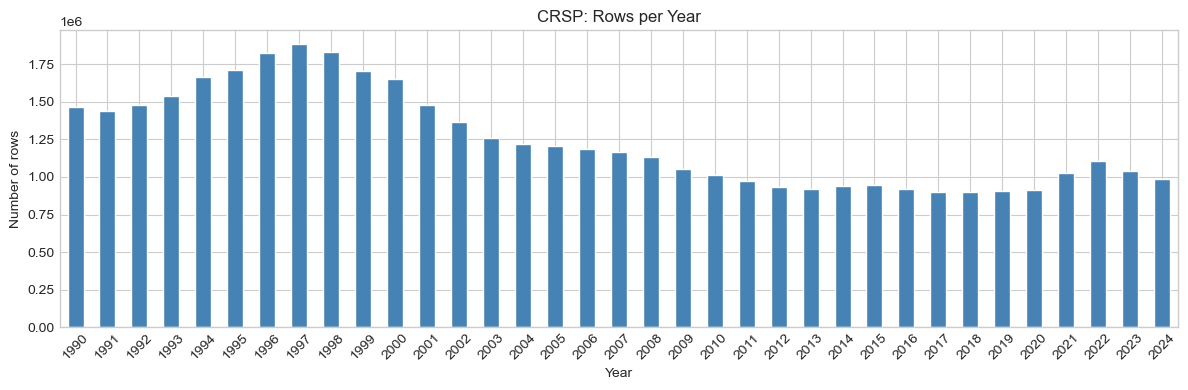

Total rows across all years: 43,717,077


In [4]:
# Row counts per year across the full CRSP dataset
year_counts = {}
for ydir in sorted(crsp_path.glob("year=*")):
    year = int(ydir.name.split("=")[1])
    year_counts[year] = len(pd.read_parquet(ydir, columns=["permno"]))

year_counts_s = pd.Series(year_counts, name="row_count")
fig, ax = plt.subplots(figsize=(12, 4))
year_counts_s.plot.bar(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("CRSP: Rows per Year")
ax.set_ylabel("Number of rows")
ax.set_xlabel("Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f"Total rows across all years: {year_counts_s.sum():,.0f}")

## 2. Fama-French Factors (Daily)</n\nMarket excess return, SMB, HML, risk-free rate, and momentum (UMD).

In [5]:
factors = pd.read_parquet(DATA_ROOT / "factors" / "factors_daily.parquet")
print(f"Shape: {factors.shape}")
print(f"Date range: {factors['date'].min()} to {factors['date'].max()}")
factors.head(10)

Shape: (8817, 6)
Date range: 1990-01-02 00:00:00 to 2024-12-31 00:00:00


,date,mktrf,smb,hml,rf,umd
0,1990-01-02,0.0144,-0.0069,-0.0006,0.0003,-0.0108
1,1990-01-03,-0.0006,0.0073,-0.0026,0.0003,-0.0031
2,1990-01-04,-0.0071,0.0042,-0.0024,0.0003,-0.0034
3,1990-01-05,-0.0085,0.0076,-0.0021,0.0003,-0.0034
4,1990-01-08,0.0030,-0.0041,-0.0027,0.0003,0.0019
5,1990-01-09,-0.0101,0.0088,0.0008,0.0003,0.0014
6,1990-01-10,-0.0076,-0.0002,0.0030,0.0003,-0.0016
7,1990-01-11,0.0023,-0.0023,0.0009,0.0003,-0.0008
8,1990-01-12,-0.0233,0.0031,0.0041,0.0003,-0.0028
9,1990-01-15,-0.0095,0.0005,0.0050,0.0003,-0.0038


In [6]:
factors.describe()

,date,mktrf,smb,hml,rf,umd
count,8817,8817.0000,8817.0000,8817.0000,8817.0000,8817.0000
mean,2007-06-26 15:19:49.384144128,0.0004,0.0000,0.0001,0.0001,0.0002
min,1990-01-02 00:00:00,-0.1201,-0.0448,-0.0503,0.0000,-0.1437
25%,1998-09-21 00:00:00,-0.0045,-0.0035,-0.0030,0.0000,-0.0034
50%,2007-06-27 00:00:00,0.0006,0.0001,-0.0001,0.0001,0.0006
75%,2016-03-30 00:00:00,0.0057,0.0035,0.0030,0.0002,0.0044
max,2024-12-31 00:00:00,0.1136,0.0545,0.0673,0.0003,0.0714
std,NaN,0.0114,0.0061,0.0070,0.0001,0.0094


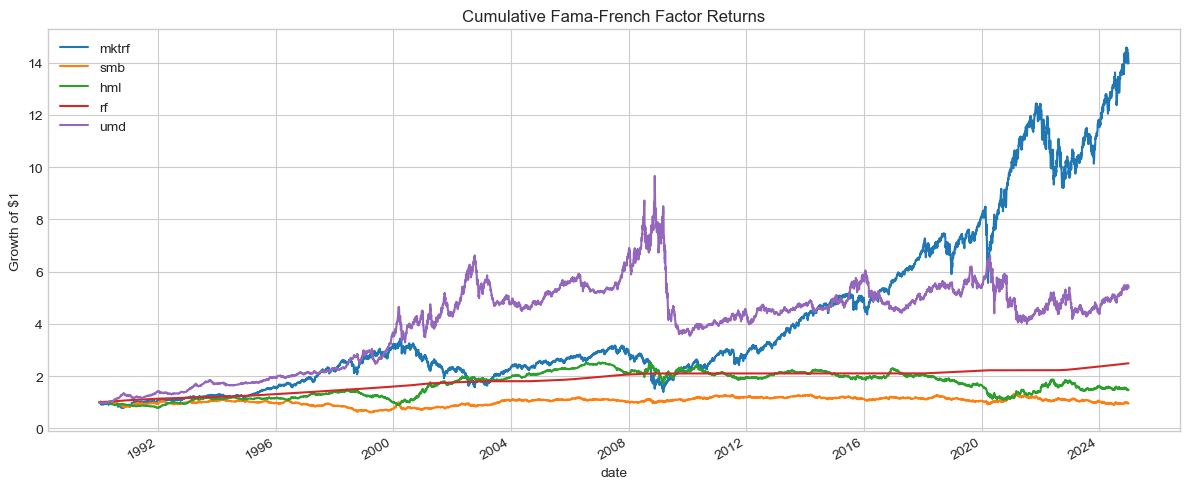

In [7]:
# Cumulative factor returns
factor_cols = [c for c in factors.columns if c != "date"]
cum = (1 + factors.set_index("date")[factor_cols]).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
cum.plot(ax=ax)
ax.set_title("Cumulative Fama-French Factor Returns")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 3. Engineered Features\n\nEach feature set is stored as a single parquet file.

In [8]:
feature_files = sorted((DATA_ROOT / "features").glob("*.parquet"))
print("Feature files:")
for f in feature_files:
    print(f"  {f.name}")

Feature files:
  cross_sectional_features.parquet
  fundamental_features.parquet
  liquidity_features.parquet
  macro_features.parquet
  momentum_features.parquet
  return_features.parquet
  targets.parquet
  volatility_features.parquet


In [9]:
# Display head + summary for each feature file
for f in feature_files:
    print("=" * 80)
    print(f"  {f.stem}")
    print("=" * 80)
    df = pd.read_parquet(f)
    print(f"Shape: {df.shape}  |  Columns: {list(df.columns)}")
    display(df.head())
    display(df.describe())
    print()

  cross_sectional_features


Shape: (40582612, 5)  |  Columns: ['date', 'permno', 'market_relative_ret', 'ret_rank', 'ret_zscore']


,date,permno,market_relative_ret,ret_rank,ret_zscore
0,1990-01-02,10001,-0.0144,0.3841,-0.2435
1,1990-01-02,10002,-0.0144,0.3841,-0.2435
2,1990-01-02,10003,0.0150,0.7787,0.3290
3,1990-01-02,10005,-0.0144,0.3841,-0.2435
4,1990-01-02,10007,0.0039,0.6946,0.1120


,date,permno,market_relative_ret,ret_rank,ret_zscore
count,40582612,40582612.0000,40569402.0000,40569402.0000,40569402.0000
mean,2003-12-16 15:58:00.626078208,61876.2526,0.0006,0.5001,0.0000
min,1990-01-02 00:00:00,10001.0000,-1.0140,0.0001,-33.1150
25%,1996-06-20 00:00:00,35238.0000,-0.0147,0.2504,-0.3415
50%,2002-06-07 00:00:00,76867.0000,-0.0007,0.4979,-0.0315
75%,2011-02-23 00:00:00,84319.0000,0.0134,0.7492,0.2943
max,2021-12-31 00:00:00,93436.0000,3.0251,1.0000,57.0883
std,NaN,28683.5958,0.0489,0.2875,0.9999



  fundamental_features


...

,permno,date,ret,retx,prc,vol,shrout,cfacpr,cfacshr,siccd,exchcd,shrcd,adj_prc,market_cap,year,excess_ret,target_ret,direction
count,36948889.0000,36948889,36936552.0000,36936552.0000,36948889.0000,36948851.0000,36948889.0000,36948889.0000,36948889.0000,36948889.0000,36948889.0000,36948889.0000,36932920.0000,36948889.0000,36948889.0000,36936552.0000,36929804.0000,36929804.0000
mean,62793.0583,2002-07-30 12:32:53.770893696,0.0010,0.0009,38.7242,596009.4199,69335.1475,1.5150,1.4507,5027.4191,2.3500,10.9777,1459.9747,2596249562.5590,2002.0772,0.0009,0.0009,0.4240
min,10001.0000,1990-01-02 00:00:00,-0.9717,-0.9717,-18800.0000,0.0000,8.0000,0.0000,0.0000,0.0000,1.0000,10.0000,0.0058,8000.0000,1990.0000,-0.9719,-0.9719,0.0000
25%,40062.0000,1995-12-14 00:00:00,-0.0153,-0.0153,3.7300,6003.0000,6408.0000,1.0000,1.0000,3570.0000,1.0000,11.0000,4.9375,37939437.5000,1995.0000,-0.0154,-0.0154,0.0000
50%,77006.0000,2001-03-05 00:00:00,0.0000,0.0000,11.7500,46350.0000,16374.0000,1.0000,1.0000,4931.0000,3.0000,11.0000,11.5650,161675375.0000,2001.0000,-0.0002,-0.0002,0.0000
75%,84210.0000,2008-07-16 00:00:00,0.0145,0.0145,25.4600,260339.0000,44331.0000,1.0000,1.0000,6512.0000,3.0000,11.0000,23.7500,813322620.0000,2008.0000,0.0144,0.0144,1.0000
max,93436.0000,2021-12-31 00:00:00,3.0000,3.0000,454550.0000,1897900032.0000,29206400.0000,480.0000,480.0000,9999.0000,3.0000,11.0000,63125000.0000,2947479964590.0000,2021.0000,2.9999,2.9999,1.0000
std,27995.5571,NaN,0.0507,0.0507,1870.1160,4440880.6766,322091.5433,3.6926,3.4996,2076.4994,0.8908,0.1478,74284.6792,18797851105.5901,8.1963,0.0507,0.0507,0.4942



  volatility_features


Shape: (38774797, 6)  |  Columns: ['date', 'permno', 'rvol_21', 'rvol_63', 'downside_vol_63', 'beta_252']


,date,permno,rvol_21,rvol_63,downside_vol_63,beta_252
0,1990-01-02,10001,NaN,NaN,NaN,NaN
1,1990-01-02,10002,NaN,NaN,NaN,NaN
2,1990-01-02,10003,NaN,NaN,NaN,NaN
3,1990-01-02,10005,NaN,NaN,NaN,NaN
4,1990-01-02,10007,NaN,NaN,NaN,NaN


,date,permno,rvol_21,rvol_63,downside_vol_63,beta_252
count,38774797,38774797.0000,38362565.0000,37571554.0000,37571554.0000,34171586.0000
mean,2003-04-04 11:47:12.638088448,62409.7639,0.0371,0.0383,0.0209,0.7997
min,1990-01-02 00:00:00,10001.0000,0.0000,0.0000,0.0000,-13.3773
25%,1996-03-20 00:00:00,38156.0000,0.0176,0.0195,0.0107,0.3339
50%,2001-10-15 00:00:00,76964.0000,0.0281,0.0301,0.0167,0.7623
75%,2009-10-21 00:00:00,84291.0000,0.0453,0.0471,0.0263,1.2024
max,2021-12-31 00:00:00,93436.0000,1.3727,0.9604,0.2683,11.1106
std,NaN,28328.7170,0.0335,0.0306,0.0153,0.6552


## 4. Fama-French 25 Portfolios (Benchmark Dataset)\n\nDaily value-weighted returns for the 5x5 size-BM sorted portfolios from Ken French's website.

In [10]:
import sys, os
# Ensure project root is on path regardless of kernel working directory
_project_root = os.path.dirname(os.path.abspath("explore_datasets.ipynb"))
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from bench.data_ff25 import load_panel

ff25 = load_panel(start="2000-01-01", end="2023-12-31", cache_dir="cache/ff25")
print(f"Returns shape: {ff25.returns.shape}")
print(f"Date range: {ff25.returns.index.min()} to {ff25.returns.index.max()}")
print(f"Assets: {list(ff25.returns.columns)}")
ff25.returns.head(10)

Returns shape: (6037, 25)
Date range: 2000-01-03 00:00:00 to 2023-12-29 00:00:00
Assets: ['SMALL LoBM', 'ME1 BM2', 'ME1 BM3', 'ME1 BM4', 'SMALL HiBM', 'ME2 BM1', 'ME2 BM2', 'ME2 BM3', 'ME2 BM4', 'ME2 BM5', 'ME3 BM1', 'ME3 BM2', 'ME3 BM3', 'ME3 BM4', 'ME3 BM5', 'ME4 BM1', 'ME4 BM2', 'ME4 BM3', 'ME4 BM4', 'ME4 BM5', 'BIG LoBM', 'ME5 BM2', 'ME5 BM3', 'ME5 BM4', 'BIG HiBM']


,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,SMALL HiBM,ME2 BM1,ME2 BM2,ME2 BM3,ME2 BM4,ME2 BM5,...,ME4 BM1,ME4 BM2,ME4 BM3,ME4 BM4,ME4 BM5,BIG LoBM,ME5 BM2,ME5 BM3,ME5 BM4,BIG HiBM
date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,0.0064,-0.0158,0.0131,-0.0086,-0.0053,-0.0170,-0.0168,-0.0095,-0.0138,-0.0118,...,-0.0044,-0.0195,-0.0196,-0.0224,-0.0217,0.0002,-0.0258,-0.0269,-0.0229,-0.0192
2000-01-04,-0.0433,-0.0389,-0.0259,-0.0199,-0.0165,-0.0402,-0.0422,-0.0211,-0.0275,-0.0290,...,-0.0498,-0.0289,-0.0215,-0.0217,-0.0250,-0.0420,-0.0374,-0.0263,-0.0264,-0.0275
2000-01-05,0.0135,0.0159,0.0103,0.0083,0.0064,0.0015,0.0031,0.0052,0.0036,0.0014,...,-0.0092,0.0036,0.0110,0.0069,-0.0022,-0.0016,0.0028,0.0073,0.0098,-0.0013
2000-01-06,0.0065,0.0115,-0.0028,0.0023,0.0088,-0.0060,-0.0084,-0.0054,-0.0002,-0.0032,...,-0.0326,0.0035,0.0106,0.0145,-0.0042,-0.0096,0.0052,0.0240,0.0180,0.0033
2000-01-07,0.0177,0.0139,0.0125,0.0242,0.0132,0.0298,0.0212,0.0148,0.0172,0.0136,...,0.0492,0.0252,0.0163,0.0146,0.0201,0.0364,0.0278,0.0162,0.0162,0.0232
2000-01-10,0.0335,0.0367,0.0146,0.0174,0.0095,0.0312,0.0256,0.0121,0.0120,0.0082,...,0.0491,0.0127,0.0034,0.0147,0.0252,0.0170,0.0052,-0.0041,0.0035,0.0044
2000-01-11,-0.0118,-0.0232,-0.0085,-0.0130,-0.0070,-0.0088,-0.0140,-0.0057,0.0000,-0.0066,...,-0.0346,-0.0141,-0.0107,-0.0078,-0.0117,-0.0132,-0.0240,-0.0065,-0.0138,-0.0083
2000-01-12,-0.0093,-0.0183,0.0015,-0.0019,-0.0023,-0.0132,-0.0043,-0.0027,0.0020,-0.0027,...,-0.0102,-0.0021,0.0009,0.0032,-0.0101,-0.0076,0.0068,0.0025,-0.0048,0.0014
2000-01-13,0.0126,0.0206,0.0179,0.0150,0.0121,0.0246,0.0178,0.0141,0.0205,0.0167,...,0.0357,0.0225,0.0137,0.0038,0.0150,0.0115,0.0258,0.0101,0.0072,0.0124


In [11]:
ff25.returns.describe()

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,SMALL HiBM,ME2 BM1,ME2 BM2,ME2 BM3,ME2 BM4,ME2 BM5,...,ME4 BM1,ME4 BM2,ME4 BM3,ME4 BM4,ME4 BM5,BIG LoBM,ME5 BM2,ME5 BM3,ME5 BM4,BIG HiBM
count,6037.0000,6037.0000,6037.0000,6037.0000,6037.0000,6037.0000,6037.0000,6037.0000,6037.0000,6037.0000,...,6037.0000,6037.0000,6037.0000,6037.0000,6037.0000,6037.0000,6037.0000,6037.0000,6037.0000,6037.0000
mean,0.0001,0.0004,0.0004,0.0005,0.0006,0.0004,0.0005,0.0005,0.0005,0.0005,...,0.0004,0.0005,0.0005,0.0005,0.0004,0.0004,0.0004,0.0004,0.0003,0.0004
std,0.0171,0.0161,0.0145,0.0146,0.0144,0.0171,0.0156,0.0151,0.0154,0.0169,...,0.0149,0.0130,0.0136,0.0140,0.0166,0.0125,0.0120,0.0125,0.0148,0.0184
min,-0.1366,-0.1334,-0.1295,-0.1459,-0.1156,-0.1541,-0.1344,-0.1149,-0.1207,-0.1470,...,-0.1217,-0.1201,-0.1233,-0.1374,-0.1755,-0.1156,-0.1117,-0.1250,-0.1383,-0.1641
25%,-0.0088,-0.0078,-0.0071,-0.0063,-0.0061,-0.0086,-0.0076,-0.0075,-0.0075,-0.0080,...,-0.0064,-0.0056,-0.0057,-0.0059,-0.0068,-0.0052,-0.0047,-0.0049,-0.0055,-0.0073
50%,0.0009,0.0010,0.0009,0.0009,0.0009,0.0011,0.0009,0.0007,0.0006,0.0007,...,0.0010,0.0009,0.0009,0.0009,0.0009,0.0008,0.0006,0.0006,0.0006,0.0007
75%,0.0096,0.0090,0.0081,0.0076,0.0076,0.0097,0.0092,0.0086,0.0086,0.0090,...,0.0079,0.0071,0.0073,0.0072,0.0079,0.0064,0.0060,0.0063,0.0065,0.0084
max,0.1122,0.1046,0.0895,0.0892,0.1416,0.0969,0.0955,0.0893,0.0882,0.1104,...,0.1123,0.1094,0.1243,0.1329,0.1380,0.1295,0.1088,0.1237,0.1381,0.1654


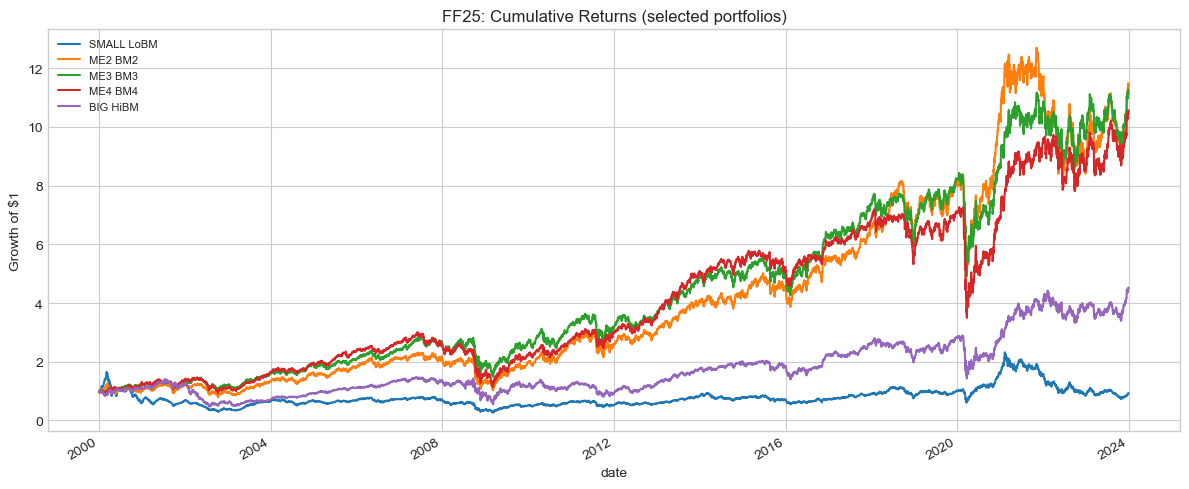

In [12]:
# Cumulative returns for a few FF25 portfolios
selected = ff25.returns.columns[::6]  # pick every 6th portfolio
cum_ff25 = (1 + ff25.returns[selected]).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
cum_ff25.plot(ax=ax)
ax.set_title("FF25: Cumulative Returns (selected portfolios)")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
# FF25 covariates
print(f"Covariates shape: {ff25.covariates.shape}")
print(f"Columns: {list(ff25.covariates.columns)}")
ff25.covariates.head(10)

Covariates shape: (150900, 5)
Columns: ['ret_lag1', 'ret_lag5', 'ret_lag21', 'vol_21', 'mom_12_1']


ret_lag1  ret_lag5  ret_lag21  vol_21  mom_12_1
date       asset_id                                                   
2000-01-04 SMALL LoBM    0.0064       NaN        NaN     NaN       NaN
           ME1 BM2      -0.0158       NaN        NaN     NaN       NaN
           ME1 BM3       0.0131       NaN        NaN     NaN       NaN
           ME1 BM4      -0.0086       NaN        NaN     NaN       NaN
           SMALL HiBM   -0.0053       NaN        NaN     NaN       NaN
           ME2 BM1      -0.0170       NaN        NaN     NaN       NaN
           ME2 BM2      -0.0168       NaN        NaN     NaN       NaN
           ME2 BM3      -0.0095       NaN        NaN     NaN       NaN
           ME2 BM4      -0.0138       NaN        NaN     NaN       NaN
           ME2 BM5      -0.0118       NaN        NaN     NaN       NaN

## 5. S&P 500 via yfinance (Benchmark Dataset)\n\nDaily adjusted close and volume for S&P 500 constituents. Note: uses current membership (survivorship bias).

In [14]:
from bench.data_yfinance import load_panel as load_yf_panel

yf_panel = load_yf_panel(
    start="2020-01-01", end="2023-12-31",
    cache_dir="cache/yfinance",
    top_n=10,
)
print(f"Returns shape: {yf_panel.returns.shape}")
print(f"Date range: {yf_panel.returns.index.min()} to {yf_panel.returns.index.max()}")
print(f"Tickers: {list(yf_panel.returns.columns)}")
yf_panel.returns.head(10)

Returns shape: (1005, 10)
Date range: 2020-01-03 00:00:00 to 2023-12-29 00:00:00
Tickers: ['AMD', 'ACN', 'ABT', 'ABBV', 'ADBE', 'AES', 'A', 'AFL', 'MMM', 'AOS']


Ticker,AMD,ACN,ABT,ABBV,ADBE,AES,A,AFL,MMM,AOS
Date,,,,,,,,,,
2020-01-03,-0.0102,-0.0017,-0.0123,-0.0095,-0.0079,-0.0115,-0.0162,-0.0070,-0.0086,-0.0088
2020-01-06,-0.0043,-0.0066,0.0052,0.0079,0.0057,0.0115,0.0030,-0.0028,0.0010,0.0063
2020-01-07,-0.0029,-0.0218,-0.0056,-0.0057,-0.0010,0.0035,0.0031,-0.0095,-0.0040,-0.0067
2020-01-08,-0.0087,0.0020,0.0041,0.0071,0.0133,-0.0020,0.0098,0.0031,0.0152,-0.0015
2020-01-09,0.0236,0.0089,0.0027,0.0077,0.0076,0.0099,0.0156,0.0002,0.0032,-0.0045
2020-01-10,-0.0165,0.0073,-0.0126,-0.0128,-0.0019,-0.0040,0.0037,-0.0082,-0.0040,0.0120
2020-01-13,0.0120,0.0093,-0.0028,-0.0061,0.0170,0.0064,-0.0015,0.0082,0.0025,0.0191
2020-01-14,-0.0111,-0.0089,0.0115,0.0098,-0.0029,0.0044,0.0060,-0.0057,0.0025,-0.0271
2020-01-15,0.0070,0.0016,0.0189,0.0119,-0.0049,0.0029,0.0071,0.0019,-0.0088,-0.0134


In [15]:
yf_panel.returns.describe()

Ticker,AMD,ACN,ABT,ABBV,ADBE,AES,A,AFL,MMM,AOS
count,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000
mean,0.0011,0.0006,0.0003,0.0007,0.0006,0.0001,0.0005,0.0005,-0.0003,0.0006
std,0.0336,0.0192,0.0175,0.0159,0.0250,0.0259,0.0192,0.0216,0.0179,0.0198
min,-0.1583,-0.0876,-0.1030,-0.1393,-0.1838,-0.1900,-0.1047,-0.1795,-0.1003,-0.0907
25%,-0.0176,-0.0085,-0.0085,-0.0070,-0.0111,-0.0111,-0.0088,-0.0080,-0.0089,-0.0104
50%,0.0000,0.0011,0.0008,0.0011,0.0015,0.0005,0.0011,0.0013,0.0000,0.0003
75%,0.0204,0.0100,0.0092,0.0086,0.0145,0.0130,0.0107,0.0095,0.0087,0.0120
max,0.1527,0.1210,0.1038,0.0836,0.1631,0.1394,0.0938,0.2325,0.1187,0.1281


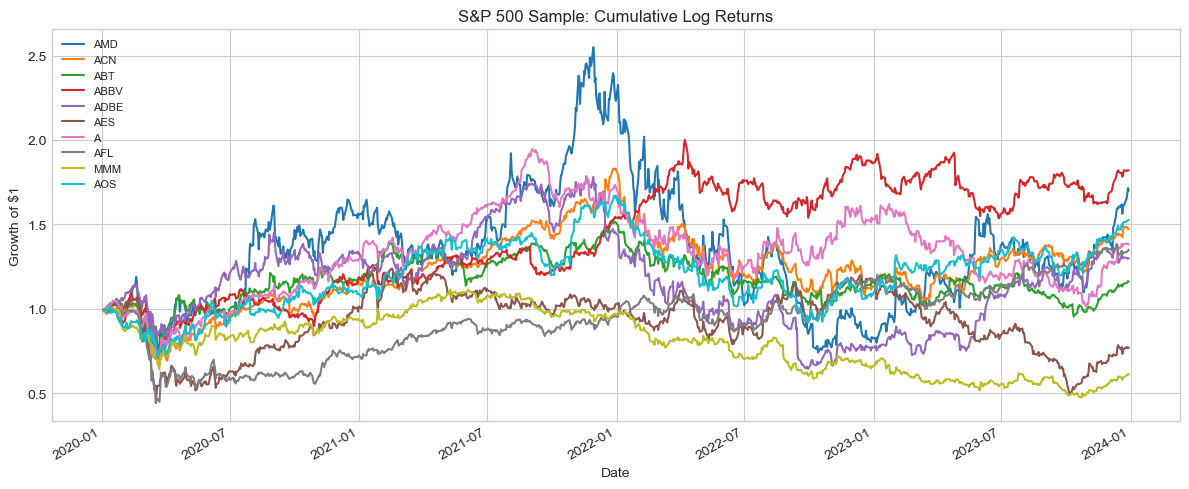

In [16]:
# Cumulative returns for the yfinance tickers
cum_yf = (1 + yf_panel.returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
cum_yf.plot(ax=ax)
ax.set_title("S&P 500 Sample: Cumulative Log Returns")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
# yfinance covariates
print(f"Covariates shape: {yf_panel.covariates.shape}")
print(f"Columns: {list(yf_panel.covariates.columns)}")
yf_panel.covariates.head(10)

Covariates shape: (10040, 6)
Columns: ['ret_lag1', 'ret_lag5', 'ret_lag21', 'vol_21', 'mom_12_1', 'log_vol_z']


ret_lag1  ret_lag5  ret_lag21  vol_21  mom_12_1  \
date       asset_id                                                    
2020-01-06 AMD        -0.0102       NaN        NaN     NaN       NaN   
           ACN        -0.0017       NaN        NaN     NaN       NaN   
           ABT        -0.0123       NaN        NaN     NaN       NaN   
           ABBV       -0.0095       NaN        NaN     NaN       NaN   
           ADBE       -0.0079       NaN        NaN     NaN       NaN   
           AES        -0.0115       NaN        NaN     NaN       NaN   
           A          -0.0162       NaN        NaN     NaN       NaN   
           AFL        -0.0070       NaN        NaN     NaN       NaN   
           MMM        -0.0086       NaN        NaN     NaN       NaN   
           AOS        -0.0088       NaN        NaN     NaN       NaN   

                     log_vol_z  
date       asset_id             
2020-01-06 AMD             NaN  
           ACN             NaN  
           ABT             NaN  
           ABBV            NaN  
           ADBE            NaN  
           AES             NaN  
           A               NaN  
           AFL             NaN  
           MMM             NaN  
           AOS             NaN

## 6. Missing Data Summary\n\nQuick overview of NaN coverage across datasets.

In [18]:
# NaN percentages for each feature file
nan_summary = {}
for f in feature_files:
    df = pd.read_parquet(f)
    nan_pct = df.isna().mean() * 100
    nan_summary[f.stem] = nan_pct

nan_df = pd.DataFrame(nan_summary).T
nan_df.columns.name = "column"
nan_df.index.name = "feature_file"
print("NaN percentage per column in each feature file:")
display(nan_df.round(2))

NaN percentage per column in each feature file:


column,adj_prc,amihud_21,asset_growth,beta_252,book_to_market,cfacpr,cfacshr,cum_ret_21,cum_ret_5,cum_ret_63,...,shrcd,shrout,siccd,target_ret,term_spread,turnover,unemployment_change,vol,volume_zscore_63,year
feature_file,,,,,,,,,,,,,,,,,,,,,
cross_sectional_features,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fundamental_features,NaN,NaN,99.6900,NaN,11.2700,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
liquidity_features,NaN,22.6200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0500,NaN,NaN,2.8800,NaN
macro_features,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0100,NaN,0.0200,NaN,NaN,NaN
momentum_features,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
return_features,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.1300,0.2900,3.3100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
targets,0.0400,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN,NaN,...,0.0000,0.0000,0.0000,0.0500,NaN,NaN,NaN,0.0000,NaN,0.0000
volatility_features,NaN,NaN,NaN,11.8700,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
